In [4]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model = init_chat_model("qwen/qwen3-32b", model_provider="groq")

response = model.invoke("Write me a joke on ML")
print(response.content)

<think>
Okay, the user wants a joke about machine learning. Let me think about common ML concepts that can be turned into a pun or a play on words.

First, there's overfitting. That's when a model learns the training data too well, including the noise. Maybe I can compare it to something everyday. Like... maybe a student who studies too much?

Or maybe underfitting? That's when the model is too simple. But overfitting is a more common term people use. Let me stick with that.

Another idea: neural networks. Maybe comparing layers to something else. Or training a model taking too long. Oh, "my model took three weeks to train, and it's still not getting the joke" – maybe?

Wait, here's a classic structure: "Why did the ML model...? Because it wanted to..." Maybe not. Let me think again.

What about data preprocessing? Like cleaning data, normalization... Maybe a joke about how much time is spent on that. There's that saying, "data cleaning takes 80% of the time..." Maybe turn that into a 

In [9]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model = init_chat_model(
    "qwen/qwen3-32b",
    model_provider="groq"
)

In [10]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"


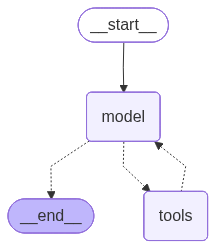

In [12]:
from langchain.agents import create_agent

agent=create_agent(
    model =model,
    tools =[get_weather],
    system_prompt = "You are a helpful assistant"

)

agent

In [13]:
response = agent.invoke({"messages":[{"role":"user","content":"What is the weather like in Bangalore?"}]})

response

{'messages': [HumanMessage(content='What is the weather like in Bangalore?', additional_kwargs={}, response_metadata={}, id='b9270e0a-8b15-442c-804d-2759b5b4b4e9'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Bangalore. I need to use the get_weather function. Let me check the function parameters. It requires a location, which is Bangalore here. I should call the function with location set to "Bangalore". Make sure the JSON is correctly formatted. No other parameters are needed. Just pass the location.\n', 'tool_calls': [{'id': 'zx45sm43r', 'function': {'arguments': '{"location":"Bangalore"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 160, 'total_tokens': 255, 'completion_time': 0.161814758, 'completion_tokens_details': {'reasoning_tokens': 70}, 'prompt_time': 0.00643484, 'prompt_tokens_details': None, 'queue_time': 0.047656909, 'total_time

In [14]:
response['messages'][-1].content

'The weather in Bangalore is currently sunny.'

In [21]:
from langchain_google_genai import ChatGoogleGenerativeAI

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

model =  ChatGoogleGenerativeAI(model="gemini-2.5-flash")

agent=create_agent(
    model =model,
    tools =[get_weather],
    system_prompt = "You are a helpful assistant"

)


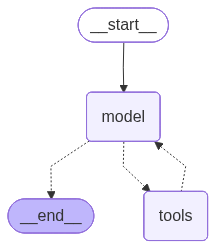

In [22]:
agent

In [23]:
response = agent.invoke({"messages":[{"role":"user","content":"What is the weather like in Bangalore?"}]})

response

{'messages': [HumanMessage(content='What is the weather like in Bangalore?', additional_kwargs={}, response_metadata={}, id='4ca42328-518d-4812-8aa8-ddb2b0779c13'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Bangalore"}'}, '__gemini_function_call_thought_signatures__': {'012c9a6c-194c-499d-a5d7-686c4054544c': 'CqICAb4+9vu5ZFsdlrADOoAuTitJJtQHZD+AFy+EIlSJdjSXBLXGdi1r61FSWHzP0gbPVkgz/vwWtZpVNMybPXhl0/VuRMXLh6E0gyPAnAKIeBLT9/M0wLc7oeIDoABPIMQbrPfwyFdZfM3Ha22CUi400cb+5qNSTtMNkqjMh7ML1IckWEwFacJHUbs8R/NkFjJtIMArhBv44EgDOLKWyoY3jbRU/zA7wG/3e+5C1HzHtfAytROgg5oo1EYVs83CwrAhATXItfUI46PnBOhzI9jVanQmDyfJqYyF+ugpU4lKBI3pRHx2KNQLwUwXC8Aejyp31IC7TkANmxuT10v7V+5cmKLdnKUZxKz251UDgyykeduKeeN/lydD7Ki+LlB+d1akouk='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d1b69-d954-7422-80a4-ba15fc268ea5-0', tool_calls=[{'name': 'get_weather'